# Predicting vulnerable employment in South America

World Development Indicators (World Bank) | Lasso feature selection + neural networks

**Target:** `Vulnerable employment, total (% of total employment) (modeled ILO estimate)`  
**Panel:** 9 South American countries, 1991-2022  
**Pipeline:** reshape WDI -> missing-value filters -> chronological train/val/test split ->
Lasso (hand-written objective, minimised with `scipy.optimize`) -> stability selection ->
feed-forward neural network, with and without country fixed effects.

See the README for results and how to reproduce.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import optimize
import tensorflow as tf
from tensorflow import keras

# Fixed seeds: the neural networks and the stability-selection subsampling
# are stochastic, so without this the numbers move between runs.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

sns.set_theme(style='whitegrid')

In [2]:
# The notebook runs on the South-America subset that ships with the repo (~9 MB).
# To start from the full World Bank release instead, run scripts/download_wdi.py
# and switch to: csv_path = '../data/raw/WDICSV.csv'
csv_path = '../data/processed/WDI_SouthAmerica_Filtered.csv'

We don't include Venezuela given the lack of reliable information.

In [3]:
south_america_countries = [
    "Argentina", "Bolivia", "Brazil", "Chile", "Colombia", "Ecuador", 
    "Guyana", "Paraguay", "Peru", "Suriname", "Uruguay"
]

Loading the data, initially we do it by chunks but its fine loading it all together

In [4]:
def load_and_filter_data(path, countries):
    df_full = pd.read_csv(path)

    df_filtered = df_full[df_full['Country Name'].isin(countries)].copy()
    
    del df_full
    
    return df_filtered

In [5]:
df_sa = load_and_filter_data(csv_path, south_america_countries)

In [6]:
df_sa = df_sa.drop(columns = ['Country Code', 'Indicator Code']).reset_index(drop = True)
df_sa

,Country Name,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Argentina,Access to clean fuels and technologies for coo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,99.800000,99.80000,99.900000,99.900000,99.900000,99.90000,99.900000,99.900000,NaN,NaN
1,Argentina,Access to clean fuels and technologies for coo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,96.900000,97.30000,97.500000,97.800000,97.800000,98.10000,98.200000,98.200000,NaN,NaN
2,Argentina,Access to clean fuels and technologies for coo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,99.900000,99.90000,99.900000,99.900000,99.900000,99.90000,99.900000,99.900000,NaN,NaN
3,Argentina,Access to electricity (% of population),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,99.900000,100.00000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,NaN,NaN
4,Argentina,"Access to electricity, rural (% of rural popul...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,99.300000,100.00000,99.900000,100.000000,100.000000,100.00000,100.000000,100.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16341,Uruguay,Women who believe a husband is justified in be...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16342,Uruguay,Women who were first married by age 15 (% of w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16343,Uruguay,Women who were first married by age 18 (% of w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16344,Uruguay,Women's share of population ages 15+ living wi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,33.923618,33.97736,34.092118,34.267522,34.479043,34.65719,34.811607,34.936986,35.029545,NaN


In [7]:
df_sa = df_sa.melt(id_vars=['Country Name', 'Indicator Name'], var_name='Year', value_name='Value')

In [8]:
df_sa

,Country Name,Indicator Name,Year,Value
0,Argentina,Access to clean fuels and technologies for coo...,1960,NaN
1,Argentina,Access to clean fuels and technologies for coo...,1960,NaN
2,Argentina,Access to clean fuels and technologies for coo...,1960,NaN
3,Argentina,Access to electricity (% of population),1960,NaN
4,Argentina,"Access to electricity, rural (% of rural popul...",1960,NaN
...,...,...,...,...
1078831,Uruguay,Women who believe a husband is justified in be...,2025,NaN
1078832,Uruguay,Women who were first married by age 15 (% of w...,2025,NaN
1078833,Uruguay,Women who were first married by age 18 (% of w...,2025,NaN
1078834,Uruguay,Women's share of population ages 15+ living wi...,2025,NaN


In [9]:
df_sa = df_sa.pivot(index=['Country Name', 'Year'], columns='Indicator Name', values='Value').reset_index()

In [10]:
df_sa

Indicator Name,Country Name,Year,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Argentina,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Argentina,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Argentina,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,Uruguay,2021,NaN,100.0,100.0,100.0,100.0,100.0,100.0,74.127268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.657190,NaN
722,Uruguay,2022,NaN,100.0,100.0,100.0,100.0,100.0,100.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.811607,NaN
723,Uruguay,2023,NaN,100.0,100.0,100.0,100.0,100.0,100.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.936986,NaN
724,Uruguay,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.745128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.029545,NaN


In [11]:
df_sa.notna().sum().sort_values(ascending = True)

Indicator Name
Net primary income (Net income from abroad) (constant LCU)      0
Net official flows from UN agencies, UNWTO (current US$)        0
Net official flows from UN agencies, UNECE (current US$)        0
Net official flows from UN agencies, UNIDIR (current US$)       0
Net official flows from UN agencies, UNCTAD (current US$)       0
                                                             ... 
Population ages 65 and above (% of total population)          715
Population ages 45-49, female (% of female population)        715
Net migration                                                 726
Year                                                          726
Country Name                                                  726
Length: 1488, dtype: int64

Now we create another dataframe keeping only variables with at least 15 years of observations per country. This is equivalent to having 11 (countries) * 15 (years) = 165 observations

In [12]:
missings = df_sa.notna().sum()
keep = missings[missings >= 165].index
df_filtered = df_sa[keep].copy()
df_filtered

Indicator Name,Country Name,Year,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)","Adjusted net enrollment rate, primary (% of primary school age children)",Adjusted net national income (annual % growth),...,"Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Argentina,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Argentina,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Argentina,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,Uruguay,2021,100.0,100.0,100.0,100.0,100.0,100.0,NaN,3.201104,...,23.129782,26.244269,24.822874,74.530436,69.101547,71.579304,13.386646,NaN,34.657190,NaN
722,Uruguay,2022,100.0,100.0,100.0,100.0,100.0,100.0,NaN,NaN,...,23.047514,26.132576,24.733243,74.594665,69.231254,71.664008,13.713013,NaN,34.811607,NaN
723,Uruguay,2023,100.0,100.0,100.0,100.0,100.0,100.0,NaN,NaN,...,23.669733,25.407852,24.624254,74.250896,69.757444,71.783072,NaN,NaN,34.936986,NaN
724,Uruguay,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.569141,25.272235,24.500610,74.329548,69.893741,71.903324,NaN,NaN,35.029545,NaN


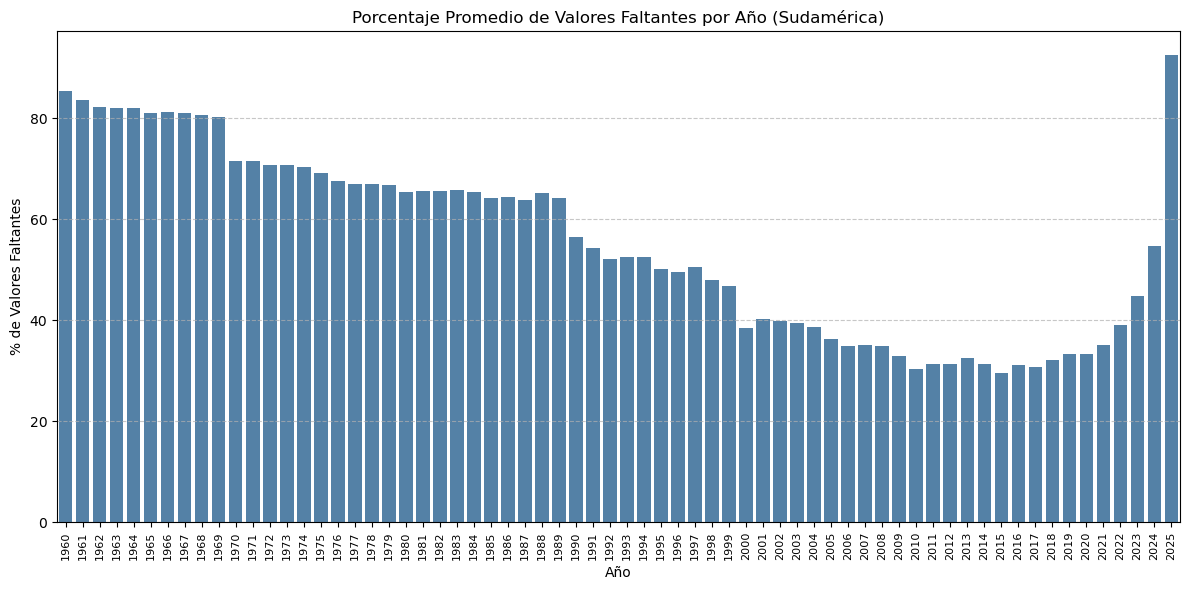

In [13]:
missings_by_year = df_sa.isnull().groupby(df_sa['Year']).sum()

# 2. Calcular el porcentaje de valores faltantes total por año (promedio de todas las columnas)
# Esto nos da una métrica de "calidad de la data" por año
total_indicators = len(df_sa.columns) - 2 # Restamos 'Country Name' y 'Year'
missing_percentage_year = (missings_by_year.sum(axis=1) / (len(south_america_countries) * total_indicators)) * 100

# 3. Visualización de la distribución de missings por año
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentage_year.index, y=missing_percentage_year.values, color='steelblue')
plt.title('Porcentaje Promedio de Valores Faltantes por Año (Sudamérica)')
plt.xlabel('Año')
plt.ylabel('% de Valores Faltantes')
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Filtrar columnas según la cantidad de valores no nulos (missing values)
missings = df_sa.notna().sum()
keep = missings[missings >= 165].index
df_filtered = df_sa[keep].copy()

We expected this results since world bank has to check the data reported by national authorities and therefore in 2024 and 2025 we would expect some lag. It is also normal that in the oldest dates we have less information since some indicators have not been created.

In [14]:
df_filtered['Year'] = df_filtered['Year'].astype('Int64')
df_filtered = df_filtered[df_filtered['Year'] >= 1990]
df_filtered = df_filtered[df_filtered['Year'] <= 2022].reset_index(drop = True)
df_filtered

Indicator Name,Country Name,Year,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)","Adjusted net enrollment rate, primary (% of primary school age children)",Adjusted net national income (annual % growth),...,"Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Argentina,1990,NaN,NaN,NaN,92.154800,78.894588,94.139015,NaN,0.344893,...,NaN,NaN,NaN,NaN,NaN,NaN,9.385735,NaN,31.181689,1800.0
1,Argentina,1991,NaN,NaN,NaN,92.492188,79.254271,94.413116,96.1759,15.472975,...,23.518997,23.981508,23.804605,74.079704,68.536062,70.656326,10.224271,NaN,31.406328,1900.0
2,Argentina,1992,NaN,NaN,NaN,92.829453,79.778635,94.686699,NaN,14.233318,...,23.306007,24.045218,23.757161,74.255297,68.484691,70.733391,11.015790,NaN,31.620163,2000.0
3,Argentina,1993,NaN,NaN,NaN,93.166046,80.333701,94.957123,NaN,5.309868,...,23.051210,24.011110,23.639321,74.490926,68.585502,70.872796,11.898279,NaN,31.826288,2000.0
4,Argentina,1994,NaN,NaN,NaN,93.501274,80.935886,95.221230,NaN,4.861248,...,22.695408,23.884755,23.415931,74.807002,68.695800,71.104791,12.569935,NaN,32.030301,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,Uruguay,2018,100.0,100.0,100.0,99.800000,100.000000,99.800000,NaN,-0.898133,...,21.919344,26.128321,24.234207,75.762547,69.162185,72.132465,13.961616,NaN,34.092118,NaN
359,Uruguay,2019,100.0,100.0,100.0,99.900000,100.000000,99.900000,NaN,1.767142,...,21.900946,26.085715,24.197277,75.767907,69.212578,72.170666,13.978528,NaN,34.267522,NaN
360,Uruguay,2020,100.0,100.0,100.0,100.000000,100.000000,100.000000,NaN,-6.960781,...,22.596184,26.813740,24.905014,75.134127,68.621622,71.569143,12.847329,NaN,34.479043,NaN
361,Uruguay,2021,100.0,100.0,100.0,100.000000,100.000000,100.000000,NaN,3.201104,...,23.129782,26.244269,24.822874,74.530436,69.101547,71.579304,13.386646,NaN,34.657190,NaN


We filter one last time. The idea is to have a final database with enough observations in order to being able to input them using bayesian analysis. Aditionally, we want to check for one last time the amount of missing per year and potentially per country, if theres not information in countries we wouldn't be able to take that variable into acocunt.

In [15]:
min_obs = int(0.70 * len(df_filtered))
missings = df_filtered.notna().sum()
keep = missings[missings >= min_obs].index
df_filtered = df_filtered[keep].copy()
df_filtered

Indicator Name,Country Name,Year,Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),...,"Use of IMF credit (DOD, current US$)","Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Argentina,1990,92.154800,78.894588,94.139015,0.344893,1.999960e+11,1.206357e+11,-1.140719,6105.647839,...,3.083196e+09,NaN,NaN,NaN,NaN,NaN,NaN,9.385735,31.181689,1800.0
1,Argentina,1991,92.492188,79.254271,94.413116,15.472975,2.309413e+11,1.668984e+11,13.824492,6949.722626,...,2.483115e+09,23.518997,23.981508,23.804605,74.079704,68.536062,70.656326,10.224271,31.406328,1900.0
2,Argentina,1992,92.829453,79.778635,94.686699,14.233318,2.638119e+11,2.040249e+11,12.662789,7829.751354,...,2.313851e+09,23.306007,24.045218,23.757161,74.255297,68.484691,70.733391,11.015790,31.620163,2000.0
3,Argentina,1993,93.166046,80.333701,94.957123,5.309868,2.778200e+11,2.109263e+11,3.893956,8134.638463,...,3.519668e+09,23.051210,24.011110,23.639321,74.490926,68.585502,70.872796,11.898279,31.826288,2000.0
4,Argentina,1994,93.501274,80.935886,95.221230,4.861248,2.913255e+11,2.271064e+11,3.465338,8416.531170,...,4.211220e+09,22.695408,23.884755,23.415931,74.807002,68.695800,71.104791,12.569935,32.030301,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,Uruguay,2018,99.800000,100.000000,99.800000,-0.898133,5.375485e+10,5.635481e+10,-1.076103,15835.709423,...,NaN,21.919344,26.128321,24.234207,75.762547,69.162185,72.132465,13.961616,34.092118,NaN
359,Uruguay,2019,99.900000,100.000000,99.900000,1.767142,5.470478e+10,5.406238e+10,1.687099,16102.873581,...,NaN,21.900946,26.085715,24.197277,75.767907,69.212578,72.170666,13.978528,34.267522,NaN
360,Uruguay,2020,100.000000,100.000000,100.000000,-6.960781,5.089690e+10,4.684765e+10,-7.009011,14974.221332,...,NaN,22.596184,26.813740,24.905014,75.134127,68.621622,71.569143,12.847329,34.479043,NaN
361,Uruguay,2021,100.000000,100.000000,100.000000,3.201104,5.252616e+10,4.999455e+10,3.270164,15463.902954,...,NaN,23.129782,26.244269,24.822874,74.530436,69.101547,71.579304,13.386646,34.657190,NaN


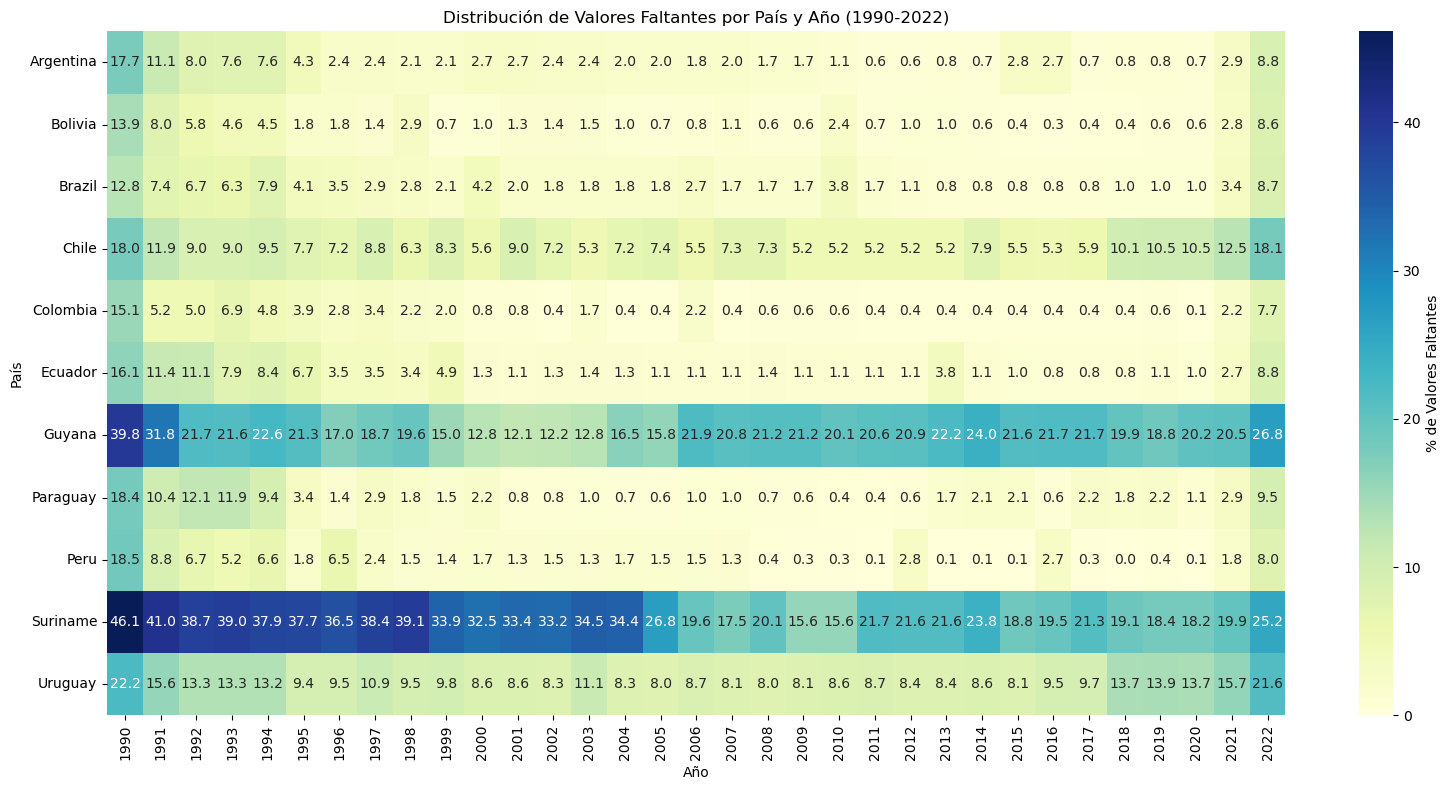

In [16]:
indicator_cols = df_filtered.columns[2:]
df_filtered['Missing_Pct'] = (df_filtered[indicator_cols].isnull().sum(axis=1) / len(indicator_cols)) * 100

# 2. Pivotar para el Heatmap: Filas=Países, Columnas=Años, Valores=% Missings
missing_matrix = df_filtered.pivot(index='Country Name', columns='Year', values='Missing_Pct')

# 3. Graficar el Heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(missing_matrix, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% de Valores Faltantes'})
plt.title('Distribución de Valores Faltantes por País y Año (1990-2022)')
plt.xlabel('Año')
plt.ylabel('País')
plt.tight_layout()
plt.show()

# Limpiar la columna auxiliar para no afectar futuros análisis
df_filtered = df_filtered.drop(columns=['Missing_Pct'])

In [17]:
df_filtered = df_filtered[~df_filtered['Country Name'].isin(['Suriname', 'Guyana'])]
df_filtered['Country Name'].unique()

array(['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador',
       'Paraguay', 'Peru', 'Uruguay'], dtype=object)

In [18]:
list(df_filtered.columns)

['Country Name',
 'Year',
 'Access to electricity (% of population)',
 'Access to electricity, rural (% of rural population)',
 'Access to electricity, urban (% of urban population)',
 'Adjusted net national income (annual % growth)',
 'Adjusted net national income (constant 2015 US$)',
 'Adjusted net national income (current US$)',
 'Adjusted net national income per capita (annual % growth)',
 'Adjusted net national income per capita (constant 2015 US$)',
 'Adjusted net national income per capita (current US$)',
 'Adjusted net savings, excluding particulate emission damage (% of GNI)',
 'Adjusted net savings, excluding particulate emission damage (current US$)',
 'Adjusted net savings, including particulate emission damage (% of GNI)',
 'Adjusted net savings, including particulate emission damage (current US$)',
 'Adjusted savings: carbon dioxide damage (% of GNI)',
 'Adjusted savings: carbon dioxide damage (current US$)',
 'Adjusted savings: consumption of fixed capital (% of GNI)',


In [19]:
interest_variable = (
    df_filtered
      .groupby(['Country Name','Year'])['Vulnerable employment, total (% of total employment) (modeled ILO estimate)']
      .apply(lambda s: s.isna().sum())
      .reset_index(name='n_missing')
)


interest_variable['n_missing'] = interest_variable['n_missing'].astype(int)
interest_variable[interest_variable['n_missing'] > 0]

,Country Name,Year,n_missing
0,Argentina,1990,1
33,Bolivia,1990,1
66,Brazil,1990,1
99,Chile,1990,1
132,Colombia,1990,1
165,Ecuador,1990,1
198,Paraguay,1990,1
231,Peru,1990,1
264,Uruguay,1990,1


In [20]:
df_filtered = df_filtered[df_filtered['Year']> 1990]

## Separate the interest variable and check for potential leakage by definition

In [21]:
df_interest_variable = (
    df_filtered[
        ['Country Name', 'Year', 'Vulnerable employment, total (% of total employment) (modeled ILO estimate)']
    ]
    .copy()
    .reset_index(drop=True)
)
df_interest_variable

Indicator Name,Country Name,Year,"Vulnerable employment, total (% of total employment) (modeled ILO estimate)"
0,Argentina,1991,23.804605
1,Argentina,1992,23.757161
2,Argentina,1993,23.639321
3,Argentina,1994,23.415931
4,Argentina,1995,23.286557
...,...,...,...
283,Uruguay,2018,24.234207
284,Uruguay,2019,24.197277
285,Uruguay,2020,24.905014
286,Uruguay,2021,24.822874


### Graph the vulnerable employement per country

In [22]:
df_filtered = df_filtered.drop(columns = 'Vulnerable employment, total (% of total employment) (modeled ILO estimate)')


In [23]:
df_filtered = df_filtered.drop(columns = [
    'Vulnerable employment, female (% of female employment) (modeled ILO estimate)',
    'Vulnerable employment, male (% of male employment) (modeled ILO estimate)',
    'Self-employed, female (% of female employment) (modeled ILO estimate)',
    'Self-employed, male (% of male employment) (modeled ILO estimate)',
    'Self-employed, total (% of total employment) (modeled ILO estimate)',
    'Contributing family workers, female (% of female employment) (modeled ILO estimate)',
    'Contributing family workers, male (% of male employment) (modeled ILO estimate)',
    'Contributing family workers, total (% of total employment) (modeled ILO estimate)',
    'Wage and salaried workers, female (% of female employment) (modeled ILO estimate)',
    'Wage and salaried workers, male (% of male employment) (modeled ILO estimate)',
    'Wage and salaried workers, total (% of total employment) (modeled ILO estimate)',
    'Self-employed, female (% of female employment) (modeled ILO estimate)',
    'Self-employed, male (% of male employment) (modeled ILO estimate)'
])

We take this variables out since by construction some may have perfect colinearity with the interest variable. Some definitions/ways of measuring chave changed through years so we prefeer to play it safe and leave only variables non employed related.

## Dealing with missing values

##### Solution #1 droping them

In [24]:
df_filtered_drop_na = df_filtered.copy()
df_filtered_drop_na = df_filtered_drop_na.dropna(axis = 1).reset_index(drop=True)

len(list(df_filtered_drop_na.columns))

429

We loose 274 variables by doing this. This is equiavlent to ~38.5 of our variables.

##### Solution #2 linear average based on t-1 and t+1

In [25]:
df_filtered_average = df_filtered.copy()
df_filtered_average[df_filtered.columns.difference(['Year','Country Name'])] = (
    df_filtered_average
    .groupby('Country Name')[df_filtered.columns.difference(['Year','Country Name'])]
    .transform(lambda x: x.interpolate(method='linear', limit_area='inside'))
)

df_filtered_average = df_filtered_average.dropna(axis = 1).reset_index(drop=True)

len(list(df_filtered_average.columns))

431

Even under this method we are only able to rescue 2 more variables. Most of the NA's come from the first or the last observation 

## Lasso regression. Can we predict vulnerable employement?

First we make scale (standarize) the data. We do it because otherwise the weigths of variables with too much variance is too high in this type of regressions.

We standarize only the split data since otherwise the test data would be contaminated with information of the train data

We are using panel data and want to test our predictive model, therefore we test with past data to test the future. We split the data this chronologically to do so.

In [26]:
train_mask = df_filtered_average['Year'] <= 2014
val_mask = (df_filtered_average['Year'] > 2014) & (df_filtered_average['Year'] <= 2018)
test_mask = df_filtered_average['Year'] > 2018

X_train_raw = df_filtered_average[train_mask].drop(columns=['Country Name', 'Year'])
X_val_raw = df_filtered_average[val_mask].drop(columns=['Country Name', 'Year'])
X_test_raw = df_filtered_average[test_mask].drop(columns=['Country Name', 'Year'])

y_train_raw = df_interest_variable[train_mask]['Vulnerable employment, total (% of total employment) (modeled ILO estimate)']
y_val_raw = df_interest_variable[val_mask]['Vulnerable employment, total (% of total employment) (modeled ILO estimate)']
y_test_raw = df_interest_variable[test_mask]['Vulnerable employment, total (% of total employment) (modeled ILO estimate)']

While standarizing we replace the std 0 to 1. This shouldn't affect the regression since it means the variable is a constant. It would have perfect colinearity with the intercept and therefore when running the regression the software would drop one of the variables (or discount it leaving one of the betas as 0).

In [27]:
def standardize_fit_transform(train, val, test):
    mu = train.mean()
    sigma = train.std()

    sigma = np.where(sigma == 0, 1, sigma)
    
    train_std = (train - mu) / sigma
    val_std = (val - mu) / sigma
    test_std = (test - mu) / sigma
    return train_std, val_std, test_std

In [28]:
y_train, y_val, y_test = standardize_fit_transform(y_train_raw, y_val_raw, y_test_raw)
X_train, X_val, X_test = standardize_fit_transform(X_train_raw, X_val_raw, X_test_raw)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

We include the constant since some of the variables have no variation on some years. If this is the case and its taken out when running the model (as the intercept) then the dimensions will not fit together.

In [29]:
X_train_const = sm.add_constant(X_train, has_constant='add')
X_val_const = sm.add_constant(X_val, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

We now create the Lasso regressions

In [30]:
def loss_lasso(w, λ, x_data, y_data):
    loss = np.sum((np.dot(x_data, w) - y_data)**2) / len(y_data) + λ * np.sum(np.abs(w))
    return loss

We are not sure about this step but apparently it is better to make the values become numpy. This way, it avoids mistakes given the function.

In [31]:
x_lasso_data = X_train_const.values
y_lasso_data = y_train.values

Theoretically one would like to run the logspace for a bigger set of numbers. Ideally checking for more values which is the best penalization. In this case due to computational power we only run it on 5 values

In [32]:
penalties = np.logspace(-3, 1, 5) 
initial_w = np.zeros(X_train_const.shape[1])
penalties

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01])

We create a logarithmic penalty since according to literature it is the fastest way to find the lambda that minimizes the MSE.

We run the model and test it on validation data. This way, we avoid data leakege and overfitting. We will finally test this on the validation but not yet.

In [33]:
best_penalty = None
best_val_mse = float('inf')
best_w = None
val_mses = []
lasso_complexities = [] 


for penalty in penalties:
    result = optimize.minimize(lambda w: loss_lasso(w, penalty, x_lasso_data, y_lasso_data), np.zeros(X_train_const.shape[1]))
    w_opt = result.x
    
    y_pred_val = np.dot(X_val_const.values, w_opt)
    
    mse_val = np.mean((y_pred_val - y_val.values)**2)
    val_mses.append(mse_val)
    
    lasso_complexities.append(np.sum(np.abs(w_opt)))
    
    print(f"Penalty: {penalty:.4f} | Validation MSE: {mse_val:.4f}")
    
    if mse_val < best_val_mse:
        best_val_mse = mse_val
        best_penalty = penalty
        best_w = w_opt

Penalty: 0.0010 | Validation MSE: 0.0507
Penalty: 0.0100 | Validation MSE: 0.0395
Penalty: 0.1000 | Validation MSE: 0.0883
Penalty: 1.0000 | Validation MSE: 0.8762
Penalty: 10.0000 | Validation MSE: 0.8762


In [34]:
best_penalty, best_val_mse

(0.01, 0.03953769211396394)

In [35]:
coef_df = pd.DataFrame({
    'indicator': X_train_const.columns,
    'betas': best_w
})

Check what is the optimal treshold

In [36]:
threshold = 0.01
surviving_vars = coef_df[coef_df['betas'].abs() > threshold].sort_values(by='betas', key=abs, ascending=False, ignore_index = True)

surviving_vars

,indicator,betas
0,"Maternal mortality ratio (modeled estimate, pe...",0.129129
1,"Employment in services, female (% of female em...",-0.112222
2,"Mortality rate, adult, female (per 1,000 femal...",0.095613
3,"Employment in industry, male (% of male employ...",-0.086978
4,GDP per capita (constant 2015 US$),-0.082628
5,Energy use (kg of oil equivalent per capita),-0.080019
6,Employment in agriculture (% of total employme...,0.070326
7,Lifetime risk of maternal death (%),0.059569
8,Electric power consumption (kWh per capita),-0.058966
9,"Manufacturing, value added (% of GDP)",-0.055550


We set the treshold since python don't drop the variables, it just makes the coefficients close to zero. Therefore, it is needed to drop at some point.

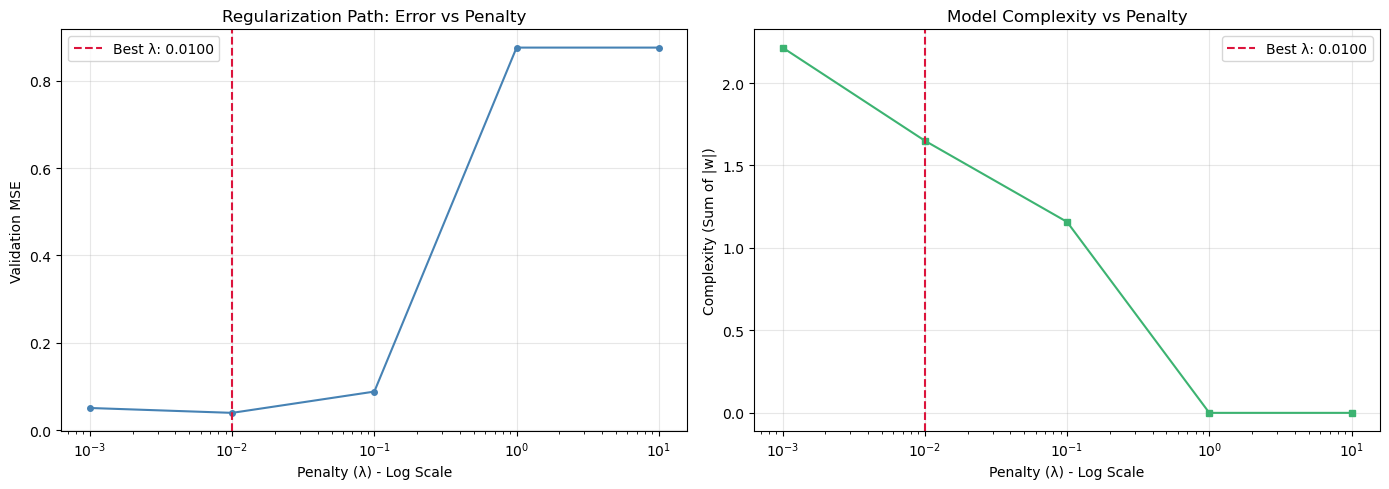

In [37]:
plt.figure(figsize=(14, 5))

# Plot 1: Validation MSE vs Penalty
plt.subplot(1, 2, 1)
plt.plot(penalties, val_mses, marker='o', markersize=4, linestyle='-', color='steelblue')
plt.axvline(best_penalty, color='crimson', linestyle='--', label=f'Best λ: {best_penalty:.4f}')
plt.xscale('log')
plt.xlabel('Penalty (λ) - Log Scale')
plt.ylabel('Validation MSE')
plt.title('Regularization Path: Error vs Penalty')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Complexity vs Penalty
plt.subplot(1, 2, 2)
plt.plot(penalties, lasso_complexities, marker='s', markersize=4, linestyle='-', color='mediumseagreen')
plt.axvline(best_penalty, color='crimson', linestyle='--', label=f'Best λ: {best_penalty:.4f}')
plt.xscale('log')
plt.xlabel('Penalty (λ) - Log Scale')
plt.ylabel('Complexity (Sum of |w|)')
plt.title('Model Complexity vs Penalty')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The graphs show that it would have been ok to run less weights. They crash after it gets close to 1. (10^0)

# Neural netowrk

Now given the variables that were selected we will run a Neural Network in order to improve the model accuracy. We choose a low Badge Size so the model doesn't overfit. 

In [38]:
selected_features = surviving_vars['indicator'].tolist()

X_train_nn = X_train_const[selected_features].values
X_val_nn = X_val_const[selected_features].values
X_test_nn = X_test_const[selected_features].values

y_train_nn = y_train.values
y_val_nn = y_val.values
y_test_nn = y_test.values

In [39]:
model = keras.Sequential([
    keras.layers.Input(shape=(len(selected_features),)),
    
    # Hidden layer 1 with Dropout
    keras.layers.Dense(32, activation='relu'), 
    keras.layers.Dropout(0.2), # Turns off 20% of neurons to prevent overfitting
    
    # Hidden layer 2 with Dropout
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    
    # Output layer (1 continuous value for regression)
    keras.layers.Dense(1)
])

In [40]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

In [41]:
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,      
    batch_size=16,   
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.6148 - mae: 0.9778 - val_loss: 0.9568 - val_mae: 0.7926
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1010 - mae: 0.8131 - val_loss: 0.4608 - val_mae: 0.5456
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6446 - mae: 0.6271 - val_loss: 0.2430 - val_mae: 0.3883
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4874 - mae: 0.5510 - val_loss: 0.1674 - val_mae: 0.3116
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4164 - mae: 0.4718 - val_loss: 0.1775 - val_mae: 0.2925
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2988 - mae: 0.4205 - val_loss: 0.1969 - val_mae: 0.2927
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2458 - mae: 0.3897 - val_loss: 0.1754 - val_mae: 0.2654
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2597 - mae: 0.3748 - val_loss: 0.1671 - val_mae: 0.2487
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2

In [42]:
pred_valid = model.predict(X_val_nn, verbose=0).squeeze()

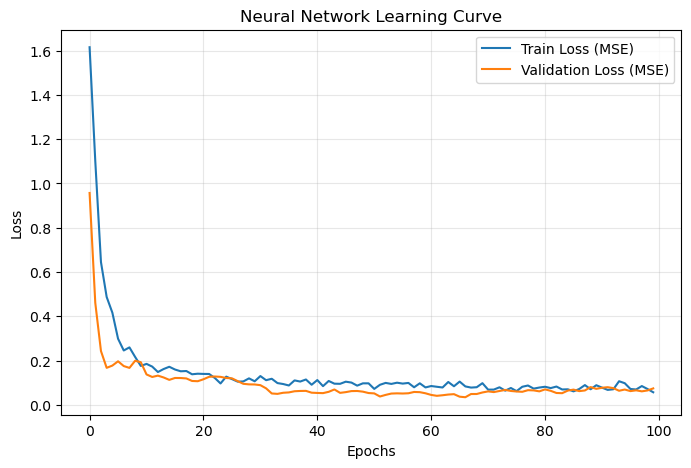

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Neural Network Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
test_loss, test_mae = model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"Final Test MSE (Loss): {test_loss:.4f}")
print(f"Final Test MAE: {test_mae:.4f}")

Final Test MSE (Loss): 1.2728
Final Test MAE: 0.4725


In [45]:
all_preds_std = np.concatenate([
    model.predict(X_train_nn, verbose=0).squeeze(),
    model.predict(X_val_nn, verbose=0).squeeze(),
    model.predict(X_test_nn, verbose=0).squeeze()
])

In [46]:
mu_y, sigma_y = y_train_raw.mean(), y_train_raw.std()
if sigma_y == 0: sigma_y = 1

all_actual_real = df_interest_variable['Vulnerable employment, total (% of total employment) (modeled ILO estimate)'].values
all_preds_real = (all_preds_std * sigma_y) + mu_y

In [47]:
plot_df = df_filtered_average[['Country Name', 'Year']].copy()
plot_df['Year'] = plot_df['Year'].astype(int)
plot_df['Actual'] = all_actual_real
plot_df['Predicted'] = all_preds_real

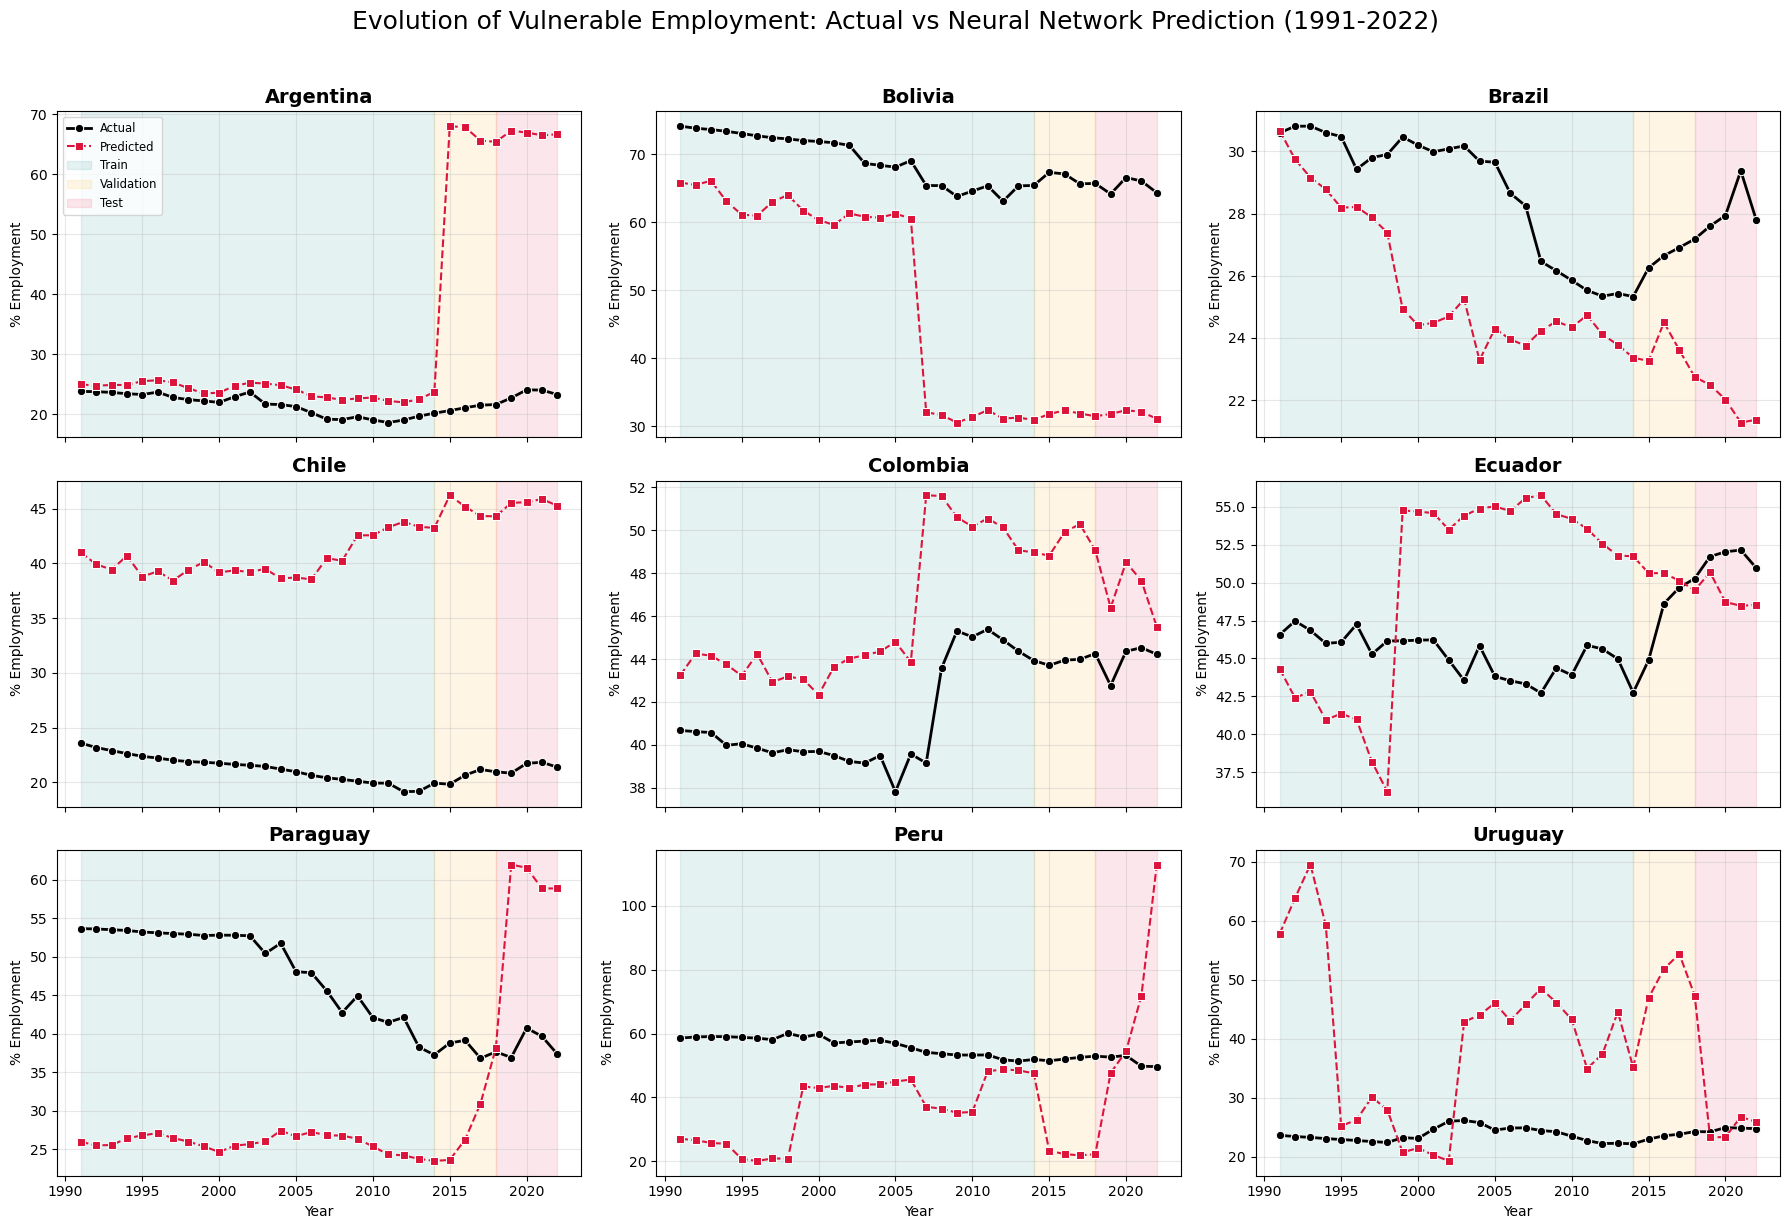

In [48]:
countries = sorted(plot_df['Country Name'].unique())
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    country_data = plot_df[plot_df['Country Name'] == country].sort_values('Year')
    
    # Graficar datos reales y predichos
    sns.lineplot(data=country_data, x='Year', y='Actual', ax=ax, label='Actual', color='black', marker='o', linewidth=2)
    sns.lineplot(data=country_data, x='Year', y='Predicted', ax=ax, label='Predicted', color='crimson', linestyle='--', marker='s')
    
    # Sombrear las fases
    ax.axvspan(1991, 2014, color='teal', alpha=0.1, label='Train' if i == 0 else "")
    ax.axvspan(2014, 2018, color='orange', alpha=0.1, label='Validation' if i == 0 else "")
    ax.axvspan(2018, 2022, color='crimson', alpha=0.1, label='Test' if i == 0 else "")
    
    ax.set_title(f'{country}', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Employment')
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper left', fontsize='small')
    else:
        ax.get_legend().remove()

plt.suptitle('Evolution of Vulnerable Employment: Actual vs Neural Network Prediction (1991-2022)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# Possible improvements

So far we can focuss on three main posibilities. 
- Imputation of data may be necessary it would be a good check to have more years and other variables. This is problematic since algorithms may take imputed values and take them as true which might not hold and may bias even more the results. It is still interesting to test it.
- Lasso algorith can improve in two different ways:
1. We can run k-fold - cross validation method on it in order to have a better selection of variables.
2. We can run a stability selection mechanism in order to have a more robust selection of variables and avoid the issues Lasso may present when there is high dimensionality and high correlation on the dataset. This would helps us to improve the consistency of the Lasso. This is specially usefull in high dimentional datasets such as the one we are working on.
- Including lags of the variables may improve the model as well. Vulnerable employement will be likely afected by the grp growth of the past years and many other examples may apply. This is specially important since we got massive spikes or jumps in the data. When using dense layers the neural network treats all points independently and therefore doesn't think that there is a relationship with past. If we include a lag of the interest variable we can very likely improve/solve this problem.  
- We can use other models as XGBoost or random forest. This models may work better for high dimentional data with few observations as the one we have.

## Lasso with stability selection

One extra excercise we though would be interesting to make is including stability selection within the Lasso, this will help us get more consistent variables and avoid different bias that may come in the regression given the way our dataframe is built.

Given the computational challenge of finding the optimal penalizing for each model, we will just run it with the optimal one find before. According to literature the selection of this parameter when doing stability selection is not a big deal.

In [49]:
n_iterations = 5
subsample_fraction = 0.5
selection_threshold = 0.80


We would run it with more iterations but it is a computational/time challenge to do so.

In [50]:
n_samples = X_train_const.shape[0]
n_features = X_train_const.shape[1]
subsample_size = int(n_samples * subsample_fraction)

In [51]:
selection_matrix = np.zeros((n_iterations, n_features))

In [52]:
lambda_ss = best_penalty

We ran it for 100 iterations but it can take up to hours. We recomend doing it for less. When running it for 100 we did get better results (still relatively bad).

In [53]:
for i in range(n_iterations):
    indices = np.random.choice(n_samples, subsample_size, replace=False)
    X_sub = X_train_const.values[indices]
    y_sub = y_train.values[indices]
    
    result_ss = optimize.minimize(lambda w: loss_lasso(w, lambda_ss, X_sub, y_sub), np.zeros(n_features))
    w_ss = result_ss.x
    
    selection_matrix[i, :] = np.abs(w_ss) > 1e-4

In [54]:
selection_probs = np.mean(selection_matrix, axis=0)

In [55]:
stability_df = pd.DataFrame({
    'indicator': X_train_const.columns,
    'selection_probability': selection_probs
})

In [56]:
stable_vars = stability_df[stability_df['selection_probability'] >= selection_threshold].sort_values(by='selection_probability', ascending=False)
stable_vars

,indicator,selection_probability
429,Women's share of population ages 15+ living wi...,1.0
396,Sex ratio at birth (male births per female bir...,1.0
382,Refugees under the mandate of the UNHCR by cou...,1.0
380,Ratio of female to male labor force participat...,1.0
267,"Mortality rate, adult, female (per 1,000 femal...",1.0
411,Trade in services (% of GDP),1.0
59,Electric power consumption (kWh per capita),1.0
228,"Maternal mortality ratio (modeled estimate, pe...",1.0
222,"Manufacturing, value added (% of GDP)",1.0
218,Lifetime risk of maternal death (%),1.0


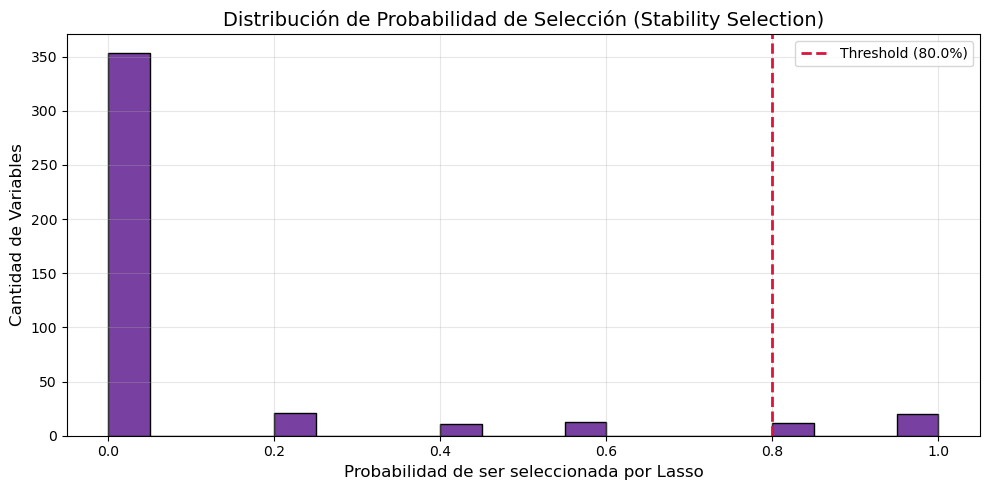

In [57]:
plt.figure(figsize=(10, 5))
sns.histplot(stability_df['selection_probability'], bins=20, color='indigo', kde=False)
plt.axvline(selection_threshold, color='crimson', linestyle='--', linewidth=2, label=f'Threshold ({selection_threshold*100}%)')
plt.title('Distribución de Probabilidad de Selección (Stability Selection)', fontsize=14)
plt.xlabel('Probabilidad de ser seleccionada por Lasso', fontsize=12)
plt.ylabel('Cantidad de Variables', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Neural network with the new variables

In [58]:
stable_features = stable_vars['indicator'].tolist()
X_train_nn_stable = X_train_const[stable_features].values
X_val_nn_stable = X_val_const[stable_features].values
X_test_nn_stable = X_test_const[stable_features].values

In [59]:
model_stable = keras.Sequential([
    keras.layers.Input(shape=(len(stable_features),)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])

In [60]:
model_stable.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
history_stable = model_stable.fit(X_train_nn_stable, y_train_nn, validation_data=(X_val_nn_stable, y_val_nn), epochs=100, batch_size=16, verbose=0)

In [61]:
all_preds_std_stable = np.concatenate([
    model_stable.predict(X_train_nn_stable, verbose=0).squeeze(),
    model_stable.predict(X_val_nn_stable, verbose=0).squeeze(),
    model_stable.predict(X_test_nn_stable, verbose=0).squeeze()
])
all_preds_real_stable = (all_preds_std_stable * sigma_y) + mu_y

plot_df['Predicted (Stable)'] = all_preds_real_stable

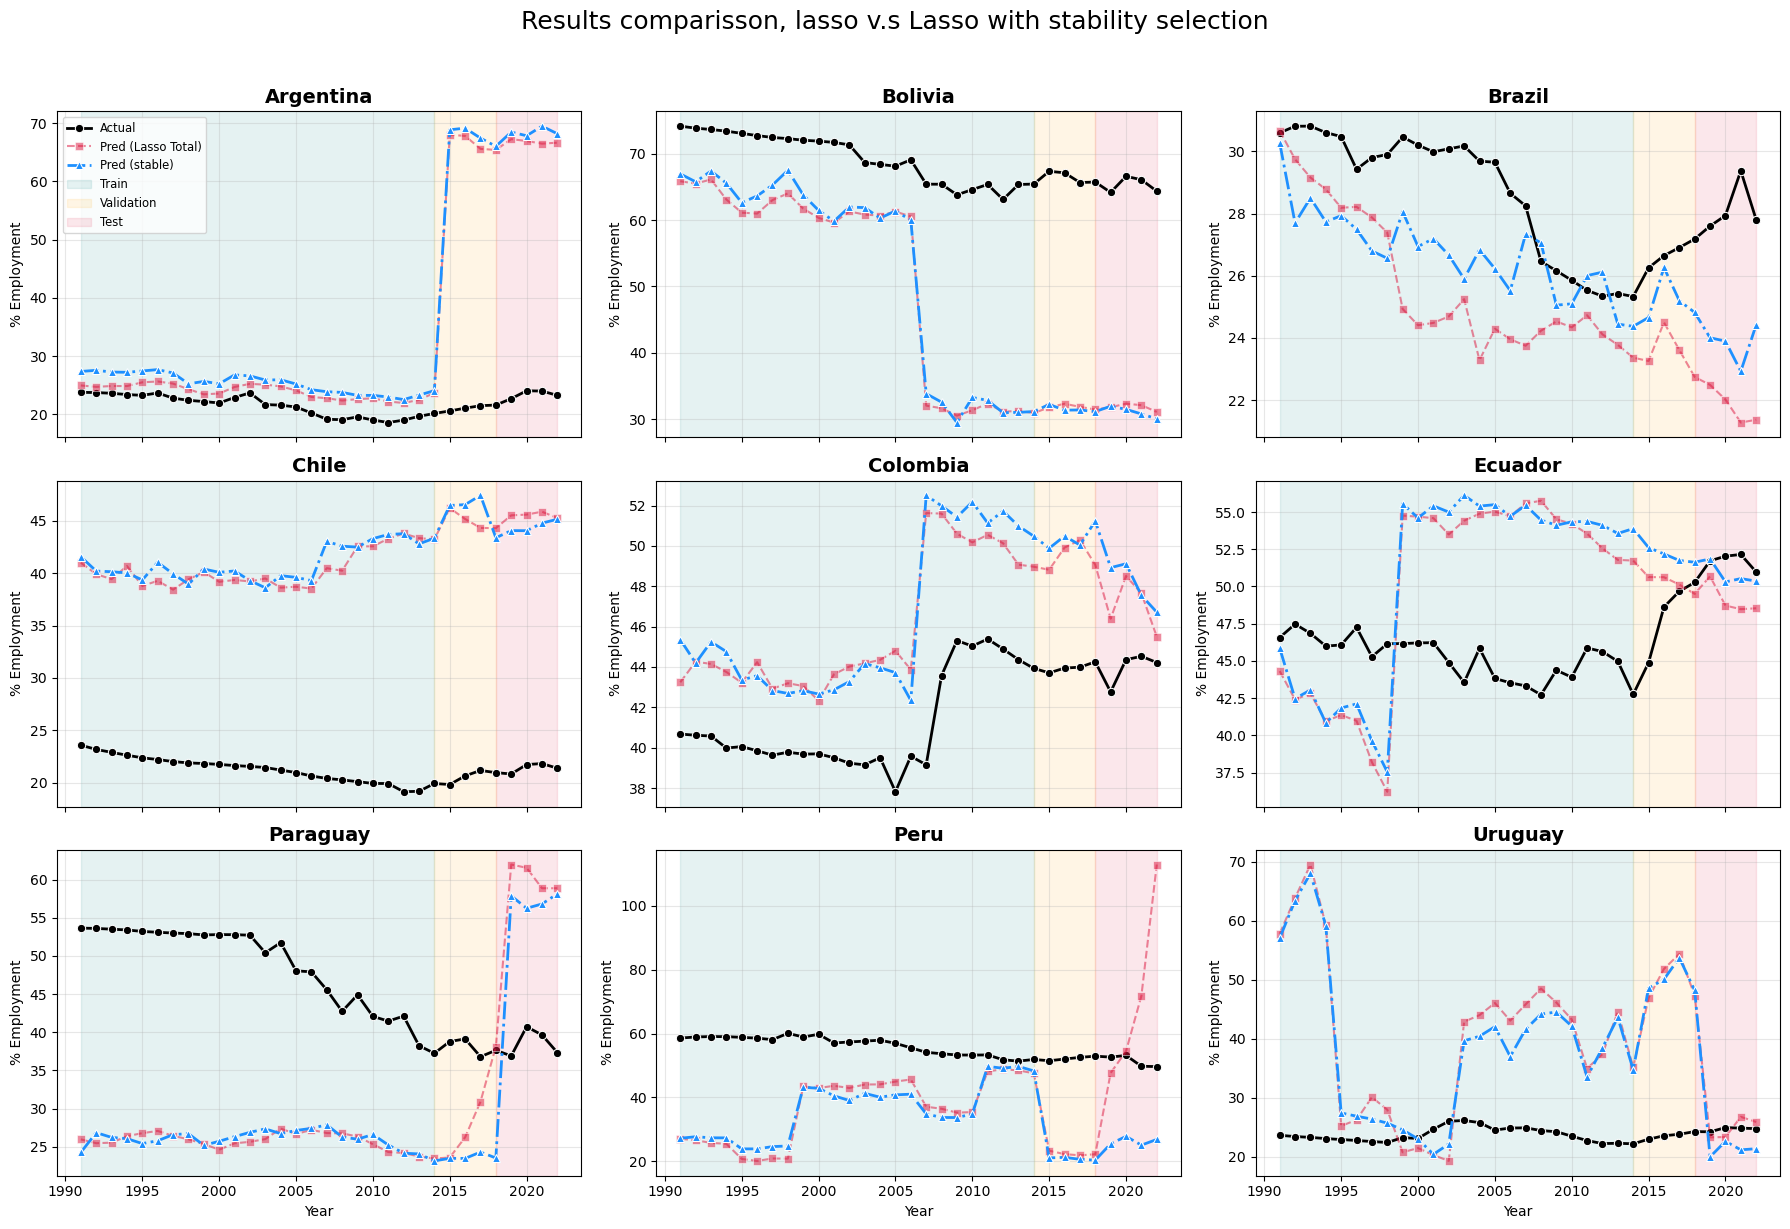

In [62]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    country_data = plot_df[plot_df['Country Name'] == country].sort_values('Year')
    
    sns.lineplot(data=country_data, x='Year', y='Actual', ax=ax, label='Actual', color='black', marker='o', linewidth=2)
    sns.lineplot(data=country_data, x='Year', y='Predicted', ax=ax, label='Pred (Lasso Total)', color='crimson', linestyle='--', marker='s', alpha=0.5)
    sns.lineplot(data=country_data, x='Year', y='Predicted (Stable)', ax=ax, label='Pred (stable)', color='dodgerblue', linestyle='-.', marker='^', linewidth=2)    
    ax.axvspan(1991, 2014, color='teal', alpha=0.1, label='Train' if i == 0 else "")
    ax.axvspan(2014, 2018, color='orange', alpha=0.1, label='Validation' if i == 0 else "")
    ax.axvspan(2018, 2022, color='crimson', alpha=0.1, label='Test' if i == 0 else "")
    
    ax.set_title(f'{country}', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Employment')
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper left', fontsize='small')
    else:
        ax.get_legend().remove()

plt.suptitle('Results comparisson, lasso v.s Lasso with stability selection', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## Country fixed effects

We will re estimate the model this time standarizing within country. This works as a fixed effects model with location fixed effects. We expect this to help solve the incercept off problem we encountered on the results. 

given the computational challenges we will just estimate this model keeping the variables that we found in the lasso with selection stability. The proper excercise would be running the lasso model again after choosing the variables but in this case it would take to long to run again.

In [63]:
X_train_df = df_filtered_average[train_mask]
y_train_df = df_interest_variable[train_mask]

In [64]:
mu_X_country = X_train_df.groupby('Country Name').mean(numeric_only=True)
sigma_X_country = X_train_df.groupby('Country Name').std(numeric_only=True).replace(0, 1).fillna(1)

mu_y_country = y_train_df.groupby('Country Name')['Vulnerable employment, total (% of total employment) (modeled ILO estimate)'].mean()
sigma_y_country = y_train_df.groupby('Country Name')['Vulnerable employment, total (% of total employment) (modeled ILO estimate)'].std().replace(0, 1).fillna(1)

In [65]:
df_X_fe = df_filtered_average.copy()
df_y_fe = df_interest_variable.copy()
cols_X = df_X_fe.columns.difference(['Country Name', 'Year'])

for country in countries:
    mask = df_X_fe['Country Name'] == country

    df_X_fe.loc[mask, cols_X] = (df_X_fe.loc[mask, cols_X] - mu_X_country.loc[country, cols_X]) / sigma_X_country.loc[country, cols_X]

    df_y_fe.loc[mask, 'Vulnerable employment, total (% of total employment) (modeled ILO estimate)'] = (df_y_fe.loc[mask, 'Vulnerable employment, total (% of total employment) (modeled ILO estimate)'] - mu_y_country.loc[country]) / sigma_y_country.loc[country]

In [66]:
X_train_fe_raw = df_X_fe[train_mask].drop(columns=['Country Name', 'Year'])
X_val_fe_raw = df_X_fe[val_mask].drop(columns=['Country Name', 'Year'])
X_test_fe_raw = df_X_fe[test_mask].drop(columns=['Country Name', 'Year'])

y_train_fe = df_y_fe[train_mask]['Vulnerable employment, total (% of total employment) (modeled ILO estimate)'].values
y_val_fe = df_y_fe[val_mask]['Vulnerable employment, total (% of total employment) (modeled ILO estimate)'].values
y_test_fe = df_y_fe[test_mask]['Vulnerable employment, total (% of total employment) (modeled ILO estimate)'].values

In [67]:
X_train_fe_const = sm.add_constant(X_train_fe_raw, has_constant='add')
X_val_fe_const = sm.add_constant(X_val_fe_raw, has_constant='add')
X_test_fe_const = sm.add_constant(X_test_fe_raw, has_constant='add')

In [68]:
X_train_nn_fe_orig = X_train_fe_const[selected_features].values
X_val_nn_fe_orig = X_val_fe_const[selected_features].values
X_test_nn_fe_orig = X_test_fe_const[selected_features].values

In [69]:
model_fe_orig = keras.Sequential([
    keras.layers.Input(shape=(len(selected_features),)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
model_fe_orig.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
model_fe_orig.fit(X_train_nn_fe_orig, y_train_fe, validation_data=(X_val_nn_fe_orig, y_val_fe), epochs=100, batch_size=16, verbose=0)

In [70]:
X_train_nn_fe_stable = X_train_fe_const[stable_features].values
X_val_nn_fe_stable = X_val_fe_const[stable_features].values
X_test_nn_fe_stable = X_test_fe_const[stable_features].values

In [71]:
model_fe_stable = keras.Sequential([
    keras.layers.Input(shape=(len(stable_features),)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
model_fe_stable.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
model_fe_stable.fit(X_train_nn_fe_stable, y_train_fe, validation_data=(X_val_nn_fe_stable, y_val_fe), epochs=100, batch_size=16, verbose=0)

In [72]:
preds_fe_orig_std = np.concatenate([
    model_fe_orig.predict(X_train_nn_fe_orig, verbose=0).squeeze(),
    model_fe_orig.predict(X_val_nn_fe_orig, verbose=0).squeeze(),
    model_fe_orig.predict(X_test_nn_fe_orig, verbose=0).squeeze()
])

preds_fe_stable_std = np.concatenate([
    model_fe_stable.predict(X_train_nn_fe_stable, verbose=0).squeeze(),
    model_fe_stable.predict(X_val_nn_fe_stable, verbose=0).squeeze(),
    model_fe_stable.predict(X_test_nn_fe_stable, verbose=0).squeeze()
])

In [73]:
plot_df['Pred_FE_Orig_Std'] = preds_fe_orig_std
plot_df['Pred_FE_Stable_Std'] = preds_fe_stable_std
plot_df['Pred_FE_Orig'] = 0.0
plot_df['Pred_FE_Stable'] = 0.0

for country in countries:
    mask = plot_df['Country Name'] == country
    mu_c = mu_y_country.loc[country]
    sig_c = sigma_y_country.loc[country]
    
    plot_df.loc[mask, 'Pred_FE_Orig'] = (plot_df.loc[mask, 'Pred_FE_Orig_Std'] * sig_c) + mu_c
    plot_df.loc[mask, 'Pred_FE_Stable'] = (plot_df.loc[mask, 'Pred_FE_Stable_Std'] * sig_c) + mu_c

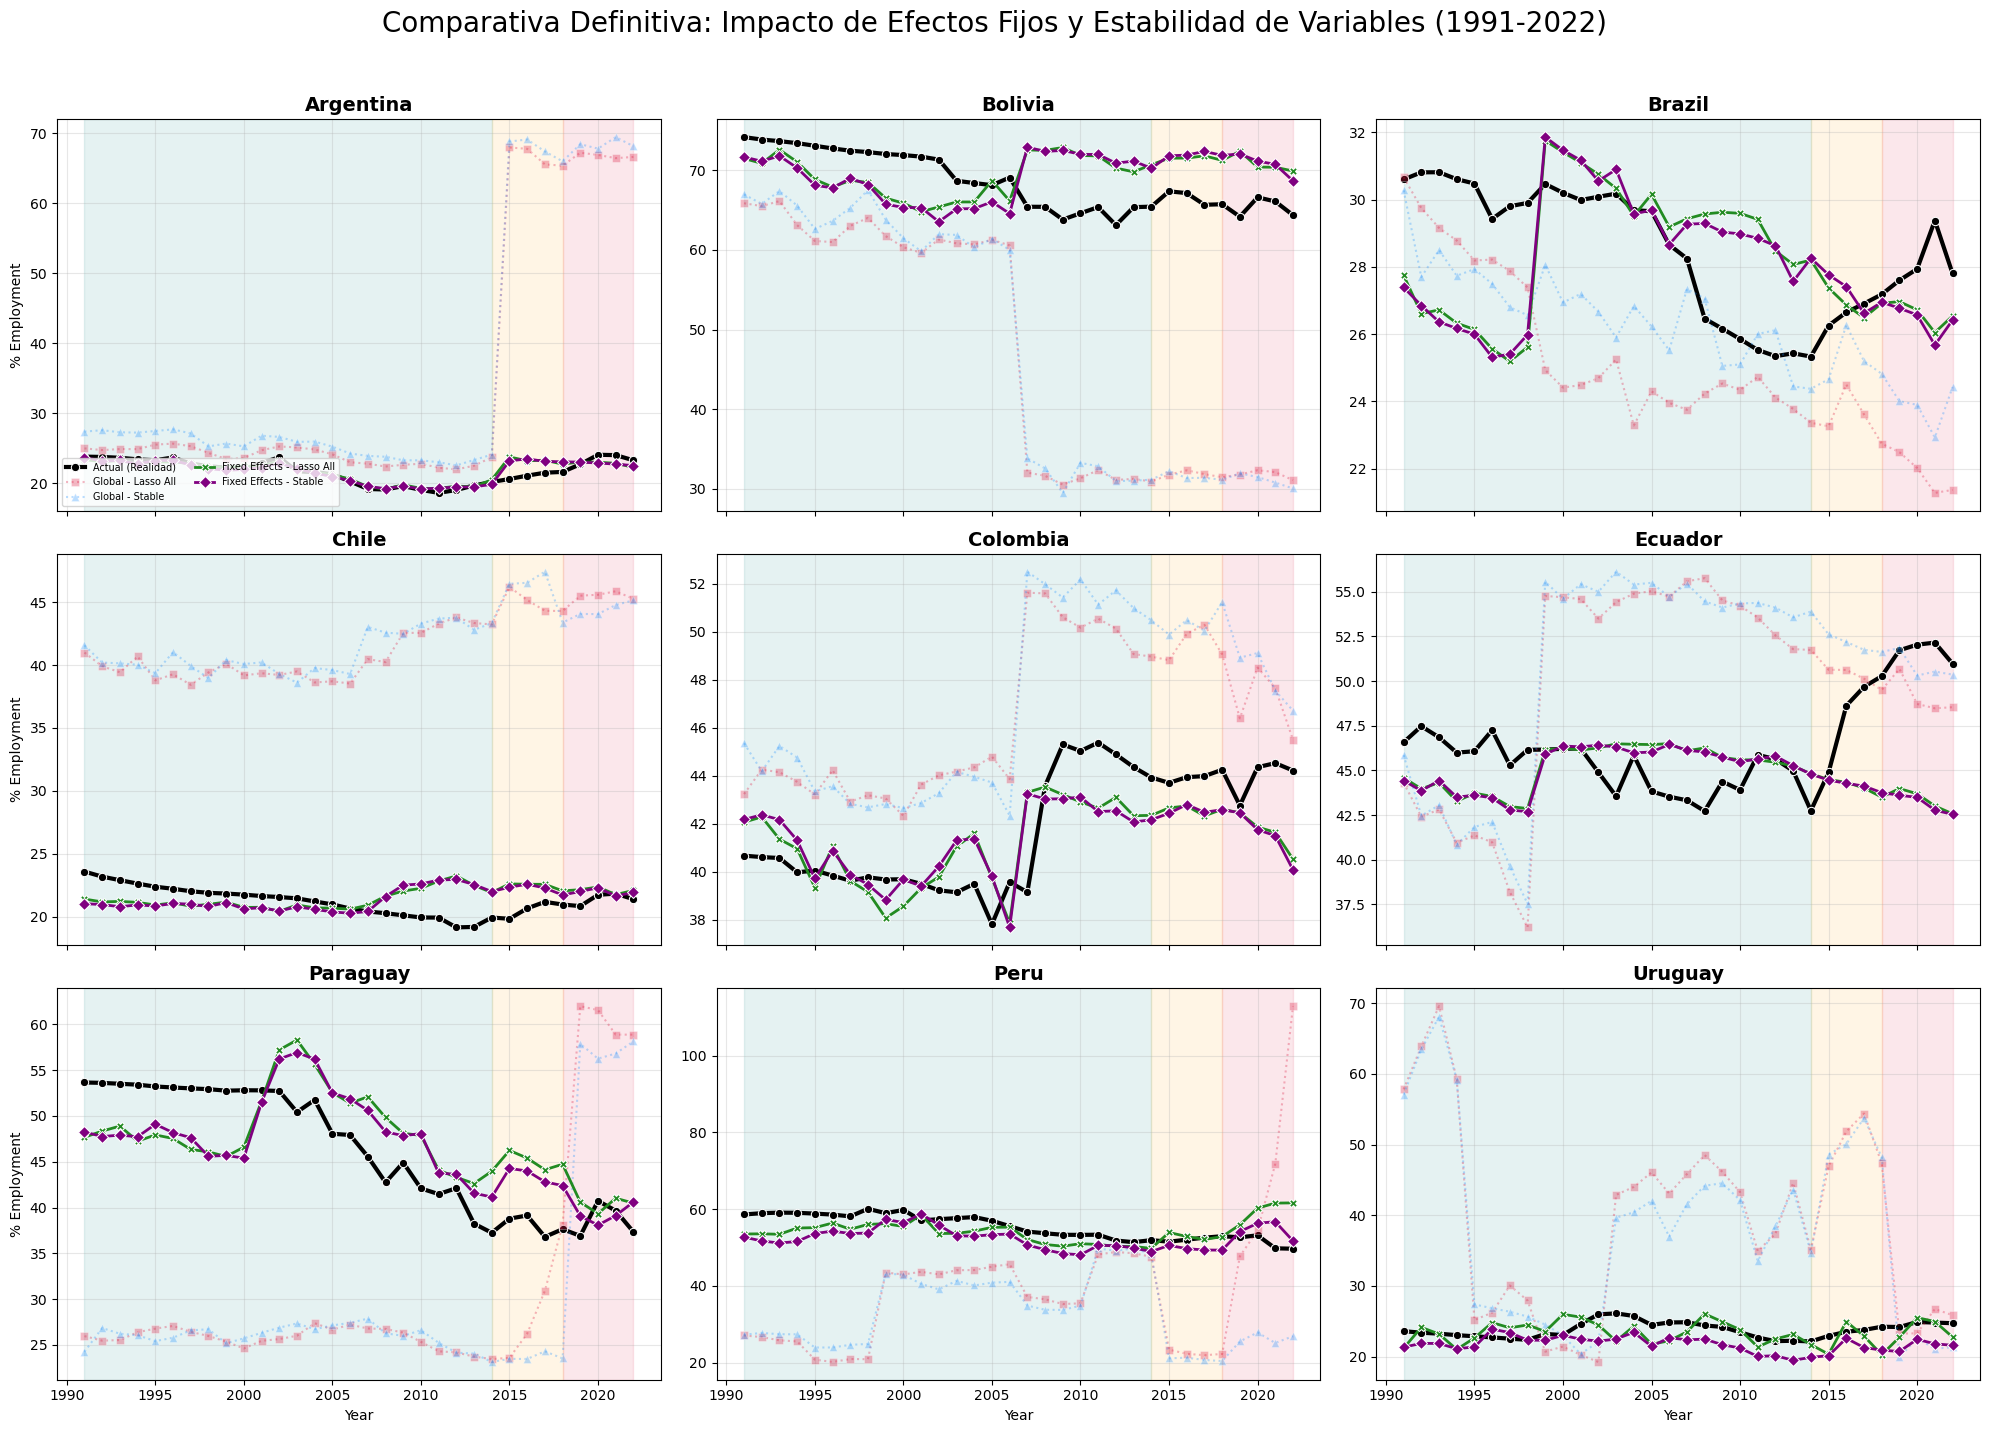

In [74]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14), sharex=True)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    country_data = plot_df[plot_df['Country Name'] == country].sort_values('Year')
    
    sns.lineplot(data=country_data, x='Year', y='Actual', ax=ax, label='Actual (Realidad)', color='black', marker='o', linewidth=3)
    
    sns.lineplot(data=country_data, x='Year', y='Predicted', ax=ax, label='Global - Lasso All', color='crimson', linestyle=':', marker='s', alpha=0.3)
    sns.lineplot(data=country_data, x='Year', y='Predicted (Stable)', ax=ax, label='Global - Stable', color='dodgerblue', linestyle=':', marker='^', alpha=0.3)
    
    sns.lineplot(data=country_data, x='Year', y='Pred_FE_Orig', ax=ax, label='Fixed Effects - Lasso All', color='forestgreen', linestyle='-', marker='X', linewidth=2)
    sns.lineplot(data=country_data, x='Year', y='Pred_FE_Stable', ax=ax, label='Fixed Effects - Stable', color='purple', linestyle='-', marker='D', linewidth=2)
    
    ax.axvspan(1991, 2014, color='teal', alpha=0.1)
    ax.axvspan(2014, 2018, color='orange', alpha=0.1)
    ax.axvspan(2018, 2022, color='crimson', alpha=0.1)
    
    ax.set_title(f'{country}', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Employment' if i % 3 == 0 else '')
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(loc='lower left', fontsize='x-small', ncol=2)
    else:
        ax.get_legend().remove()

plt.suptitle('Comparativa Definitiva: Impacto de Efectos Fijos y Estabilidad de Variables (1991-2022)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [75]:
if 'Phase' not in plot_df.columns:
    plot_df['Phase'] = 'Train'
    plot_df.loc[plot_df['Year'] > 2014, 'Phase'] = 'Validation'
    plot_df.loc[plot_df['Year'] > 2018, 'Phase'] = 'Test'

metrics_data = []
models_to_evaluate = {
    'Global - Lasso All': 'Predicted',
    'Global - Stable': 'Predicted (Stable)',
    'Fixed Effects - Lasso All': 'Pred_FE_Orig',
    'Fixed Effects - Stable': 'Pred_FE_Stable'
}

for model_name, col_name in models_to_evaluate.items():
    # Calculate MAE for each phase
    train_mae = np.mean(np.abs(plot_df[plot_df['Phase'] == 'Train']['Actual'] - plot_df[plot_df['Phase'] == 'Train'][col_name]))
    val_mae = np.mean(np.abs(plot_df[plot_df['Phase'] == 'Validation']['Actual'] - plot_df[plot_df['Phase'] == 'Validation'][col_name]))
    test_mae = np.mean(np.abs(plot_df[plot_df['Phase'] == 'Test']['Actual'] - plot_df[plot_df['Phase'] == 'Test'][col_name]))
    
    metrics_data.append({
        'Modelo': model_name,
        'Train MAE (%)': round(train_mae, 2),
        'Validation MAE (%)': round(val_mae, 2),
        'Test MAE (%)': round(test_mae, 2)
    })

metrics_df = pd.DataFrame(metrics_data)
print("\nError Absoluto Medio (MAE) en puntos porcentuales:")
print(metrics_df.to_string(index=False))


Error Absoluto Medio (MAE) en puntos porcentuales:
                   Modelo  Train MAE (%)  Validation MAE (%)  Test MAE (%)
       Global - Lasso All          12.80               20.04         17.65
          Global - Stable          12.69               21.20         17.64
Fixed Effects - Lasso All           2.45                2.81          3.48
   Fixed Effects - Stable           2.64                2.84          3.15
